# State Schema with DataClasses
+ When we define a LangGraph StateGraph, we use a state schema
+ The state schema represents the structure and type of data that our graph will use
+ All nodes will communicate with that schema
+ LangGraph offers flexibility in how you define your state schema, accommodating various Python types and validation approaches!

In [ ]:
# TypeDict State
from typing_extensions import TypedDict
from typing import Literal

class TypeDictState(TypedDict):
    name:str
    game:Literal['football','video_game']

In [8]:
def play_game(state:TypeDictState):
    print("play_game node is running")
    return {"name":state['name']+'want to play '}

def football(state:TypeDictState):
    print("football node is running")
    return {"name":state["name"]+"football","game":"football"}

def video_game(state:TypeDictState):
    print("video_game node is running")
    return {"name":state["name"]+"video_game","game":"video_game"}


In [12]:
import random

def decide_play(state:TypeDictState)->Literal['football','video_game']:
    if random.random() > 0.5:
        return "football"
    else:
        return "video_game"

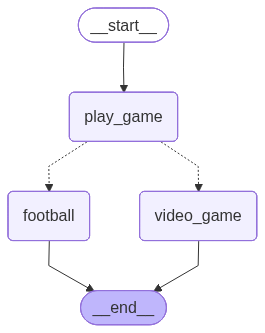

In [13]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

graph = StateGraph(TypeDictState)

graph.add_node("play_game",play_game)
graph.add_node("football",football)
graph.add_node("video_game",video_game)

graph.add_edge(START,"play_game")
graph.add_conditional_edges("play_game",decide_play)
graph.add_edge("football",END)
graph.add_edge("video_game",END)

graph_builder = graph.compile()
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [14]:
graph_builder.invoke({"name":"Thinh"})

play_game node is running
football node is running


{'name': 'Thinhwant to play football', 'game': 'football'}

# Dataclasses
+ Python's dataclasses provide another way to define structured data
+ Dataclasses offer a conscise syntax for creating classes that are primarily used to store data

In [15]:
# Create state dict using dataclass
from dataclasses import dataclass

@dataclass
class DataClassState:
    name:str
    game:Literal['football','video_game']

In [16]:
def play_game(state:DataClassState):
    print("play_game node is running")
    return {"name":state.name+'want to play '}

def football(state:DataClassState):
    print("football node is running")
    return {"name":state.name+"football","game":"football"}

def video_game(state:DataClassState):
    print("video_game node is running")
    return {"name":state.name+"video_game","game":"video_game"}


In [17]:
import random

def decide_play(state:DataClassState)->Literal['football','video_game']:
    if random.random() > 0.5:
        return "football"
    else:
        return "video_game"

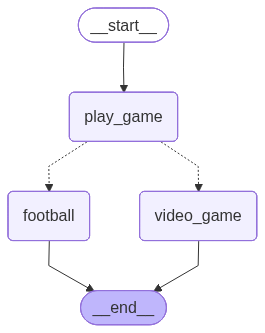

In [18]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

graph = StateGraph(DataClassState)

graph.add_node("play_game",play_game)
graph.add_node("football",football)
graph.add_node("video_game",video_game)

graph.add_edge(START,"play_game")
graph.add_conditional_edges("play_game",decide_play)
graph.add_edge("football",END)
graph.add_edge("video_game",END)

graph_builder = graph.compile()
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [19]:
graph_builder.invoke(DataClassState(name="Thinh ",game=""))

play_game node is running
football node is running


{'name': 'Thinh want to play football', 'game': 'football'}